<a href="https://colab.research.google.com/github/IlyaNicko/Motorica/blob/main/%22Motorica_one_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><font size="6">Хакатон от Моторики</font>

[Первый этап](https://www.kaggle.com/competitions/motorica-gesture-classification-task/data)

Команда 1


In [ ]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# графические библиотеки
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# библиотеки машинного обучения
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# отображать по умолчанию длину дата Датафрейма
pd.set_option("display.max_rows", 9, "display.max_columns", 9)

# библиотека взаимодействия с интерпретатором
import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")
import os

In [ ]:
# загрузка файлов с Гугл диска
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# классы и функции получения и предобработки данных для загрузки в модель
#
# x_train = DataRaw('X_train.npy', '/content/drive/MyDrive/Motorica/') параметры по дефолту
# обращение к x_train см. ниже в Загрузка Датасета
#
# функции описываются с декоратором @preproc
# должны возвращать кортеж: DataFrame, список активных датчиков
# x_train2 = DataToModel(preproc_f, x_)   , где
#                        preproc_f - функция обработки,
#                        x_ - объект DataRaw
# print(x_train2.df)
# print(x_train2.sensors)
#
# Список функций предобработки:
# e_1 - модель Эрика из N1_second_2022.09.10

def preproc(func):
    def w(x_):
        result = func(x_)
        return result
    return w


@preproc
def e_1(x_):
    sens_numbers = []
    for i in range(x_.sensors):
        sensors = pd.DataFrame(data=x_.data[:, i, :],
                               index=range(x_.length), columns=range(x_.td))
        if sensors.mean().mean() > 200:
            sens_numbers.append(i)

    df = pd.DataFrame(columns=[f'sensor_{s}' for s in sens_numbers])
    for i in range(x_.length):
        sensors = pd.DataFrame(data=x_.data[i, sens_numbers, :],
                               index=range(len(sens_numbers)), columns=range(x_.td)).T
        # применяем нормирование
        df.loc[i, [f'sensor_{s}' for s in sens_numbers]] = \
        (sensors.iloc[30:].mean() - sensors.iloc[:30].mean()).values.reshape(-1)

    return df / np.abs(df).max(), sens_numbers


class DataRaw:
    def __init__(self, file: str = 'X_train.npy',
                 adr: str = '/content/drive/MyDrive/Motorica/'):
        self.adr = adr + file
        self.data = np.load(self.adr)
        self.length = len(self.data)
        self.sensors = len(self.data[0])
        self.td = len(self.data[0][0])

# Остаются ДатаФрейм и сенсоры, которые остаются в работе
class DataToModel:
    def __init__(self, preproc_f, x_):
        self.df, self.sensors = preproc_f(x_)

In [ ]:
# Загрузка Датасета
x_train = DataRaw()
#print(f"файл 'X_train'")
#print(x_train.length)
#print(x_train.sensors)
#print(x_train.td)
#display(x_train.data) # файл большой, его можно не выводить на экран

y_train = pd.read_csv('/content/drive/MyDrive/Motorica/y_train.csv', index_col='Id').reset_index(drop = True)
print(f"файл 'y_train'")
display(y_train.head())

x_test = DataRaw('X_test.npy')

print(f"Размерность файла 'x_train': {x_train.data.shape}. Параметры: наблюдения, датчики, время")
print(f"Размерность файла 'y_train': {y_train.shape}")

файл 'y_train'


,Class
0,5
1,8
2,11
3,9
4,14


Размерность файла 'x_train': (165, 40, 60). Параметры: наблюдения, датчики, время
Размерность файла 'y_train': (165, 1)


## Данные

По условию соревнования компания Моторика передала для анализа файлы данных:

* X_train.npy - Данные представляют из себя 165 временных рядов, где в каждый момент времени фиксируются показания от датчиков, а также целевая переменная — жест;
* X_test.npy - тестовая выборка;
* Y_train.npy - целевая переменная для обучающей выборки, которая содержит следующие классы:

| Номер <br> класса | Описание |
| :---: | :--- |
| "0"  |  разгиб жеста "grab" |
| "1"  |  разгиб жеста "ok" |
| "2"  |  разгиб большого пальца |
| "3"  |  разгиб указательного пальца |
| "4"  |  разгиб жеста "пистолет" |
| "5"  |  разгиб среднего пальца |
| "6"  |  разгиб безымянного пальца |
| "7"  |  разгиб мизинца |
| "8"  |  сгиб мизинца |
| "9"  |  сгиб безымянного пальца |
| "10" |  сгиб среднего пальца |
| "11" |  сгиб жеста "пистолет" |
| "12" |  сгиб указательного пальца |
| "13" |  сгиб большого пальца |
| "14" |  сгиб жеста "ok" |
| "15" |  сгиб жеста "grab" |

В базе данных X_train имеется 165 временных рядов (далее - наблюдений) от 16 жестов. Для удобства идентификации наблюдений относительно жеста следующую индексацию: "наблюдение x-y", где:
* x - номер класса жеста;
* y - номер наблюдения из трехмерного массива x_train.

# Aнализ жеста 0 разгиб жеста "grab"
Выполним анализ жеста 0 и посмотрим на данные.

In [ ]:
# Создаем пустой список для наблюдений жеста 0. Добавим транспонирование: колонки - датчики, индексы - время от 0 до 60
gesture_0 = list() # разгиб жеста "grab"

# цикл выбора наблюдений по жестам
for i in range(165):
    if y_train['Class'].iloc[i] == 0:
        gesture_0.append(i)

print(f"Наблюдения жеста 0: {gesture_0}")

Наблюдения жеста 0: [9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159]


Рассмотрим первое по порядку наблюдение 0-9. Для этого создадим отдельный массив.

In [ ]:
# создадим массивы по всем наблюдениям жеста 0
df_0_ = {}
for i in gesture_0:
    df_0_[i] = pd.DataFrame(data = x_train.data[i], index = range(40), columns = range(60)).T

display(df_0_[9].head(1))
print(f"Размер массива наблюдения 0-9: {df_0_[9].shape}")

,0,1,2,3,...,36,37,38,39
0,1593.0,14.0,1546.0,40.0,...,1532.0,26.0,786.0,28.0


Размер массива наблюдения 0-9: (60, 40)


Отобразим показания датчиков на линейной диаграмме.

In [ ]:
# Линейная диаграмма
fig_1 = px.line(
    data_frame=df_0_[9],
)

fig_1.update_layout(
    title=dict(text='Рис. 1 - все датчики <br> наблюдение 0-9', x=.5, xanchor='center'),
    xaxis_title_text = 'Время', yaxis_title_text = 'Сигнал датчикачика',
    legend_title_text= 'Номер датчика',
    #yaxis_type='log',# логарифмическая шкала по оси У
    width=600, height=400,
)
#fig_1.update_yaxes(type="log", range=[0,4]) # предели измерений оси У. Log range: 10^0=1, 10^4=10000

fig_1.add_hrect(
    y0="0", y1="200",
    fillcolor="yellow", opacity=0.5,
    layer="below", line_width=0,
)

fig_1.show();
#fig_1.write_image('/content/drive/MyDrive/Motorika/figures/fig_1.png', engine="kaleido")

"""
# сохраним результат в папку figures.
with open('/content/drive/MyDrive/Motorika/figures/fig_1.png', 'w') as f:
  f.write('fig_1')
""";

Анализируя Рис.1 отметим, что датчики можно условно разделить на 2 группы по их амплитуде их показний на:
- активные  (0, 2, 5, 8, 12, 15, 17, 19, 21, 24, 27, 29, 30, 33, 36, 38). Их величина превышает 200;
- спящие (все остальные), величина менее 200.

Оставим на диаграмме только группу активных датчиков.

In [ ]:
# Создадим список индексов активных датчиков, чьи средние показания превышают порог в 200 единиц.
active_sensors_0_9, passive_sensors_0_9  = list(), list()

# Цикл поиска по графам-датчикам
for sensor in df_0_[9].columns:
    if df_0_[9][sensor].mean() > 200:
        active_sensors_0_9.append(sensor)
    else:
        passive_sensors_0_9.append(sensor)

print(f"Активные датчики наблюдения 0-9: {active_sensors_0_9}")
#print(f"Пассивные датчики: {passive_sensors_0_9}")

Активные датчики наблюдения 0-9: [0, 2, 5, 8, 12, 15, 17, 19, 21, 24, 27, 29, 30, 33, 36, 38]


In [ ]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Рис. 2 - Активные датчики <br> наблюдение 0-9",
                                    "Рис. 3 - Пассивные датчики <br> наблюдение 0-9"))
df = df_0_[9][active_sensors_0_9]
df_1 = df_0_[9][passive_sensors_0_9]

for i in df.columns:
    fig.add_trace(go.Scatter(x=df.index, y=df[i]),
    row=1, col=1
)

for j in df_1.columns:
    fig.add_trace(go.Scatter(x=df_1.index, y=df_1[j]),
    row=1, col=2
)

fig.update_layout(width=1100, height=400, legend_title_text ='Номер датчика',
                  xaxis_title_text  = 'Время', yaxis_title_text  = 'Сигнал датчикачика', yaxis_range = [0, 3500],
                  xaxis2_title_text = 'Время', yaxis2_title_text = 'Сигнал датчикачика', yaxis2_range= [0,  200]
)

fig.show()

На Рис.2 представлены показания активных датчиков наблюдения 0-9, а на рис.3 - пассивных датчиков. Рассматривая динамику показаний активных датчиков во времени отметим 3 периода:
*  0 - 35 с. - "покой" и слабого изменения;
* 35 - 45 с. - "сильное колебание" показаний при движении;
* 45 - 60 с. - "стабилизаця" после движения.
Показания пассивных датчиков колеблются с низкой амплитудой

В результате анализа наблюдения 0-9 "разгиб жеста "grab" установлено, что датчики можно условно разделить:
- по амплитуде сигнала на 2 группы: активные и пассивные,
- по изменению во времени на 3 группы: "покой", "сильное колебание" и "стабилизация".

Проверим активность датчиков у жеста-антагониста №15 "сгиб жеста "grab".

#Анализ жеста 15 "сгиб жеста "grab"

In [ ]:
# загрузка жеста номер 15. Добавим транспонирование: колонки - датчики, индексы - время от 0 до 60
gesture_15 = list() # разгиб жеста "grab"

# цикл выбора наблюдений по жестам
for i in range(165):
    if y_train['Class'].iloc[i] == 15:
        gesture_15.append(i)

print(f"Наблюдения жеста 15: {gesture_15}")

Наблюдения жеста 15: [21, 26, 29, 40, 54, 76, 81, 90, 116, 157, 163]


Исследуем произвольно выбранное наблюдение 15-21.

In [ ]:
# создадим массивы по этим наблюдениям
df_15_= {}
for i in gesture_15:
    df_15_[i] = pd.DataFrame(data = x_train.data[i], index = range(40), columns = range(60)).T
    #display(df[i].head(1))

#print(f"Размер массива наблюдения 1 (время и датчики): {df0.shape}")
display(df_15_[21].head(1))

,0,1,2,3,...,36,37,38,39
0,832.0,13.0,1146.0,17.0,...,1747.0,24.0,402.0,23.0


In [ ]:
# Создадим список индексов активных датчиков, чьи средние показания превышают порог в 200 единиц.
active_sensors_15_21 = list()

# Цикл поиска по графам-датчикам
for sensor in df_15_[21].columns:
    if df_15_[21][sensor].mean() > 200:
        active_sensors_15_21.append(sensor)

print(f"Активные датчики наблюдения 15-21: {active_sensors_15_21}")

Активные датчики наблюдения 15-21: [0, 2, 5, 8, 12, 15, 17, 19, 21, 24, 27, 29, 30, 33, 36, 38]


Построим диаграмму сигналов

In [ ]:
# Линейная диаграмма
df = df_15_[21]
df_active = df_15_[21][active_sensors_15_21]

fig = px.line(
    data_frame=df,
    x=df.index,
    y=df.columns
)

fig.update_layout(
    title=dict(text='Рис. 4 - все датчики <br> наблюдение 15-21', x=.5, xanchor='center'),
    xaxis_title_text = 'Время',
    yaxis_title_text = 'Сигнал датчика',
    width=600, height=400,
)

fig.add_hrect(
    y0="0", y1="200",
    fillcolor="yellow", opacity=0.5,
    layer="below", line_width=0,
)
fig.show();
#fig.write_image('figures/fig.png')

In [ ]:
# Линейная диаграмма
fig = px.line(
    data_frame=df_15_[21][active_sensors_15_21],
    #title='Рис. 5'
)

fig.update_layout(
    title=dict(text='Рис. 5 - активные датчики <br> наблюдение 15-21', x=.5, xanchor='center'),
    xaxis_title_text = 'Время',
    yaxis_title_text = 'Сигнал датчика',
    width=600, height=400,
)

fig.add_hrect(
    y0="0", y1="200",
    fillcolor="yellow", opacity=0.5,
    layer="below", line_width=0,
)
fig.show();

# Анализ активности датчиков

## а) при выполнении различных жестов

Сравним показания активных датчиков с одинаковыми индексами в ходе выполнения  жестов:
* 0  - разгиб жеста "grab"
* 15 - сгиб жеста "grab"

In [ ]:
# Создадим список индексов активных датчиков наблюдения , чьи средние показания превышают порог в 200 единиц.
# список наблюдений
#observ_list_0  = list([9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159])
#observ_list_15 = list([21, 26, 29, 40, 54, 76, 81, 90, 116, 157, 163])

# пустые списки для активных и пассивных датчиков
active_sensors_0   = list()
active_sensors_15  = list()
passive_sensors_0  = list()
passive_sensors_15 = list()

# Цикл по наблюдениям
for i in gesture_0:
  #print(i)
  # Цикл поиска по графам-датчикам
  for sensor in df_0_[i].columns:
    if df_0_[i][sensor].mean() > 200:
      active_sensors_0.append(sensor)
    else:
      passive_sensors_0.append(sensor)

for j in gesture_15:
  # Цикл поиска по графам-датчикам
  for sensor in df_15_[j].columns:
    if df_15_[j][sensor].mean() > 200:
      active_sensors_15.append(sensor)
    else:
      passive_sensors_15.append(sensor)

active_sensors_0 = pd.DataFrame({'Жест_0':active_sensors_0})
active_sensors_15 = pd.DataFrame({'Жест_15':active_sensors_15})
active_sensors_0_15 = active_sensors_0.join(active_sensors_15)

if list(active_sensors_0['Жест_0']) == list(active_sensors_15['Жест_15']):
  print("Да, массивы одинаковые")
  display(active_sensors_0_15.head())
else:
  print("no")

Да, массивы одинаковые


,Жест_0,Жест_15
0,0,0
1,2,2
2,5,5
3,8,8
4,12,12


В результате анализа установлено, что при жестах-антагонистах 15 и 0 наблюдается активность одинаковых датчиков во всех наблюдениях: 0, 2, 5, 8, 12, 15, 17, 19, 21, 24, 27, 29, 30, 33, 36, 38. Остальные датчики неактивны.

## б)при выполнении одного жеста

Выберем произвольно 4 датчика: 0, 2, 5, 33, а затем рассмотрим их активность во всех наблюдениях жестов 0 и 15.

In [ ]:
# Создадим пустой массив для списка индексов активных датчиков
sensors_0_0, sensors_0_2, sensors_0_5, sensors_0_33 = [], [], [], []
df_0_0  = pd.DataFrame(columns = sensors_0_0)
df_0_2  = pd.DataFrame(columns = sensors_0_2)
df_0_5  = pd.DataFrame(columns = sensors_0_5)
df_0_33 = pd.DataFrame(columns = sensors_0_33)

# цикл по наблюдениям жеста 0
for i in gesture_0:
    df_0_[i] = pd.DataFrame(data = x_train.data[i], index=range(40)).T  # columns = range(60)
    # фильтруем датчик №0
    df1 = df_0_[i][0]
    df_0_0 = pd.concat([df_0_0, df1], axis=1)
# объединим все датчики в датафрейм
df_0_0.columns = list(map(lambda x: f'{x}-0', list([9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159])))
sensors_0_0 = df_0_0

# цикл по наблюдениям жеста 0
for i in gesture_0:
    df_0_[i] = pd.DataFrame(data = x_train.data[i], index=range(40)).T  # columns = range(60)
    # фильтруем датчик №2
    df1 = df_0_[i][2]
    df_0_2 = pd.concat([df_0_2, df1], axis=1)
# объединим все датчики в датафрейм
df_0_2.columns = list(map(lambda x: f'{x}-2', list([9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159])))
sensors_0_2 = df_0_2

# цикл по наблюдениям жеста 0
for i in gesture_0:
    df_0_[i] = pd.DataFrame(data = x_train.data[i], index=range(40)).T  # columns = range(60)
    # фильтруем датчик №5
    df1 = df_0_[i][5]
    df_0_5 = pd.concat([df_0_5, df1], axis=1)
# объединим все датчики в датафрейм
df_0_5.columns = list(map(lambda x: f'{x}-5', list([9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159])))
sensors_0_5 = df_0_5

# цикл по наблюдениям жеста 0
for i in gesture_0:
    df_0_[i] = pd.DataFrame(data = x_train.data[i], index=range(40)).T  # columns = range(60)
    # фильтруем датчик №33
    df2 = df_0_[i][33]
    df_0_33 = pd.concat([df_0_33, df2], axis=1)
df_0_33.columns = list(map(lambda x: f'{x}-33', list([9, 10, 22, 36, 61, 96, 109, 114, 142, 148, 159])))
sensors_0_33 = df_0_33

display(sensors_0_0.head(1))
display(sensors_0_0.shape)

display(sensors_0_2.head(1))
display(sensors_0_2.shape)

display(sensors_0_5.head(1))
display(sensors_0_5.shape)

display(sensors_0_33.head(1))
display(sensors_0_33.shape)

,9-0,10-0,22-0,36-0,...,114-0,142-0,148-0,159-0
0,1593.0,1524.0,1403.0,1437.0,...,1482.0,1511.0,1288.0,1108.0


(60, 11)

,9-2,10-2,22-2,36-2,...,114-2,142-2,148-2,159-2
0,1546.0,1992.0,1905.0,2026.0,...,1905.0,1892.0,1705.0,1476.0


(60, 11)

,9-5,10-5,22-5,36-5,...,114-5,142-5,148-5,159-5
0,2195.0,2315.0,2126.0,2349.0,...,2232.0,2223.0,2025.0,1650.0


(60, 11)

,9-33,10-33,22-33,36-33,...,114-33,142-33,148-33,159-33
0,1251.0,1223.0,1234.0,1267.0,...,1232.0,1288.0,1300.0,1302.0


(60, 11)

Построим диаграмму показаний датчиков.

In [ ]:
fig = make_subplots(
    rows=2, cols=2, subplot_titles=(
        "Рис. 6 - датчик 0 <br> ", "Рис. 7 - датчик 2  <br> ",
        "Рис. 8 - датчик 5 <br> ", "Рис. 9 - датчик 33 <br> ",
        )
)

df_1 = sensors_0_0
df_2 = sensors_0_2
df_3 = sensors_0_5
df_4 = sensors_0_33

for i in df_1.columns:
    fig.add_trace(go.Scatter(x=df_1.index, y=df_1[i]), row=1, col=1)

for i in df_2.columns:
    fig.add_trace(go.Scatter(x=df_2.index, y=df_2[i]), row=1, col=2
)

for i in df_3.columns:
    fig.add_trace(go.Scatter(x=df_3.index, y=df_3[i]), row=2, col=1)

for i in df_4.columns:
    fig.add_trace(go.Scatter(x=df_4.index, y=df_4[i]), row=2, col=2
)
fig.update_layout(height=800, width=1000, #yaxis_type='log',
                  title_text="Показания датчиков в наблюдениях жеста 0", title_xanchor='left', title_font=dict(size = 22),
                  xaxis_title_text  = 'Время', yaxis_title_text  = 'Сигнал датчикачика', yaxis_range =[500 ,2500],
                  xaxis2_title_text = 'Время', yaxis2_title_text = 'Сигнал датчикачика', yaxis2_range=[500 ,2500],
                  xaxis3_title_text = 'Время', yaxis3_title_text = 'Сигнал датчикачика', yaxis3_range=[500 ,2500],
                  xaxis4_title_text = 'Время', yaxis4_title_text = 'Сигнал датчикачика', yaxis4_range=[1000,1500],
                  showlegend=False # легенда загромождает картинку
)

fig.show()

На диаграммах рис.6, 7, 8, 9 можно увидеть, что показания датчиков изменяются во времени с разной амплитудой. Амплитуда сигналов датчиков 0, 2, 5 сильнее, чем у датчика 33. Однако, изменения показаний у датчиков в разных наблюдениях одного жеста в среднем имеют одинаковый периодический характер:
*  0 - 35 с. - "покой" и слабого изменения;
* 35 - 45 с. - "сильное колебание" показаний при движении;
* 45 - 60 с. - "стабилизаця" после движения.

Исходя из сказанного можно предположить, что распределение на активные и пассивные датчики сохраняется в остальных жестах.

# Модель машинного обучения

Построим модель машинного обучения для показаний всех датчиков в каждом наблюдении. Возьмем разницу показаний датчиков перед выполнением жеста и после его завершения,- то есть между первой и второй половиной временного промежутка.

In [ ]:
# Переобразование данных
x_train2 = DataToModel(e_1, x_train)
x_train2.df.head()

,sensor_0,sensor_2,sensor_5,sensor_8,...,sensor_30,sensor_33,sensor_36,sensor_38
0,-0.322415,-0.906504,-0.882662,-0.416513,...,-0.021892,0.18361,0.407812,0.115573
1,0.10119,0.152996,0.141613,0.047951,...,0.143453,-0.307306,-0.136602,0.016987
2,0.252245,0.298878,0.491868,0.294616,...,0.124916,-0.058369,-0.534124,-0.044776
3,-0.176803,0.255322,-0.07598,-0.128858,...,0.033426,-0.296869,-0.48047,0.123233
4,0.169184,-0.122656,-0.277946,0.251874,...,0.417149,0.51179,-0.25147,0.557541


In [ ]:
x_test2 = DataToModel(e_1, x_test)
x_test2.df.head()

,sensor_0,sensor_2,sensor_5,sensor_8,...,sensor_30,sensor_33,sensor_36,sensor_38
0,0.117128,0.583908,0.473575,0.138561,...,0.024886,-0.166667,-0.614656,-0.092702
1,0.000282,0.0792,0.192984,0.094579,...,-0.53642,-0.42971,0.365635,-0.688961
2,0.194259,0.975123,0.835525,0.278691,...,-0.010253,-0.302536,-0.736071,-0.122586
3,0.062858,0.076715,0.01139,0.329833,...,0.349497,0.798551,0.156665,0.734296
4,-0.388719,-0.333763,-0.273008,-0.401023,...,-0.316619,-0.55,0.690208,0.048689


!!! Тут нужно первые три строчки удалить

In [ ]:
"""sens_cols = []
for i in range(x_train.data.shape[1]):
    sens_cols.append('sensor_' + str(i)) # Добавим префикс 'sensor_' к имени каждой графы

df = pd.DataFrame(columns = sens_cols)

# таблица разниц показаний датчиков
for i in range(x_train.data.shape[0]):
    sensors = pd.DataFrame(data = x_train.data[i], index = range(40), columns = range(60)).T
    df.loc[i, sens_cols] = (sensors.iloc[30:].mean() - sensors.iloc[:30].mean()).values.reshape(-1)

display(df)
x_train2 = df"""

"sens_cols = []\nfor i in range(x_train.data.shape[1]):\n    sens_cols.append('sensor_' + str(i)) # Добавим префикс 'sensor_' к имени каждой графы\n\ndf = pd.DataFrame(columns = sens_cols)\n\n# таблица разниц показаний датчиков\nfor i in range(x_train.data.shape[0]):\n    sensors = pd.DataFrame(data = x_train.data[i], index = range(40), columns = range(60)).T\n    df.loc[i, sens_cols] = (sensors.iloc[30:].mean() - sensors.iloc[:30].mean()).values.reshape(-1)\n\ndisplay(df)\nx_train2 = df"

Воспользуемся моделью логистической регрессии с интервалами, нормированием и регуляризацией **Log30NL1**.

In [ ]:
# Разделим массив показаний датчиков на 4 части примерно по 40 значений c равным соотношением классов
n = 4
cv_splitter = StratifiedKFold(n_splits = n)

# Создаем таблицу для сохранения результатов и счетчик
metric_table = pd.DataFrame()
i = 0

# Перебираем гиперпараметры модели (коэффициенты регуляризатора)
for C in [0.01, 0.05, 0.1, 1, 5, 10, 50, 100]:
    for penalty in ['l1', 'l2']: # два варианта регуляризации: зануление и выравнивание коэффициентов
        for solver in ['saga', 'liblinear']: # 2 типа решателей
            cl = LogisticRegression(solver = solver, penalty = penalty, C = C)

            cv_res = cross_validate(
                cl,
                x_train2.df,
                y_train,
                scoring= 'f1_macro', # метрика f1
                n_jobs = -1,
                cv = cv_splitter,
                return_train_score = True,
                verbose = 0)

            cv_train = cv_res['train_score'].mean()
            cv_test = cv_res['test_score'].mean()

            # результат отображаем в таблице
            metric_table.loc[i, 'cv_train'] = cv_train
            metric_table.loc[i, 'cv_test'] = cv_test
            metric_table.loc[i, 'C'] = C
            metric_table.loc[i, 'penalty'] = penalty
            metric_table.loc[i, 'solver'] = solver

            i +=1

metric_table['cv_dif'] = metric_table['cv_train'] - metric_table['cv_test']

metric_table.sort_values(by = 'cv_test', ascending=False).head(10)

,cv_train,cv_test,C,penalty,solver,cv_dif
17,1.000000,0.989286,5.0,l1,liblinear,0.010714
30,1.000000,0.983929,100.0,l2,saga,0.016071
28,1.000000,0.983929,100.0,l1,saga,0.016071
26,1.000000,0.983929,50.0,l2,saga,0.016071
...,...,...,...,...,...,...
21,1.000000,0.982143,10.0,l1,liblinear,0.017857
22,0.997879,0.978571,10.0,l2,saga,0.019308
18,0.997879,0.978571,5.0,l2,saga,0.019308
24,1.000000,0.977679,50.0,l1,saga,0.022321


Отсортируем таблицу по качеству показателя, лучший из которых 0.989 у солвера 'liblinear', penalty 'l1' и коэффициент C=5. Подставим эти параметры в модель.

In [ ]:
n = 4
cv_splitter = StratifiedKFold(n_splits = n)

metric_table = pd.DataFrame()
i = 0

penalty = 'l1'
C = 5
solver = 'liblinear'
cl = LogisticRegression(solver = solver, penalty = penalty, C = C)

cv_res = cross_validate(
    cl,
    x_train2.df,
    y_train,
    scoring= 'f1_macro',
    n_jobs = -1,
    cv = cv_splitter,
    return_train_score = True,
    verbose = 0)

cv_train = cv_res['train_score'].mean()
cv_test = cv_res['test_score'].mean()

# результат отображаем в таблице
metric_table.loc[i, 'cv_train'] = cv_train
metric_table.loc[i, 'cv_test'] = cv_test
metric_table.loc[i, 'C'] = C
metric_table.loc[i, 'penalty'] = penalty

metric_table['cv_dif'] = metric_table['cv_train'] - metric_table['cv_test']
print(f'отображаем результат')
metric_table.sort_values(by = 'cv_dif', ascending=False).head()

отображаем результат


,cv_train,cv_test,C,penalty,cv_dif
0,1.0,0.989286,5.0,l1,0.010714


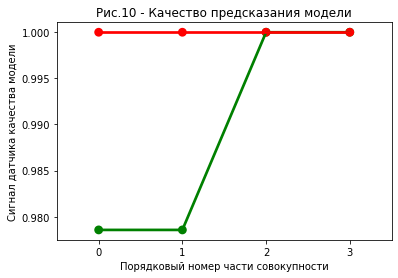

In [ ]:
#fig = plt.figure(figsize=(6, 4))
sns.pointplot(df= cv_res,
              x=np.arange(n),
              y=cv_res['test_score'], color = 'g'
              )
plot = sns.pointplot(df= cv_res,
              x=np.arange(n),
              y=cv_res['train_score'], color='r',
)
plot.set_xlabel('Порядковый номер части совокупности')
plot.set_ylabel('Сигнал датчика качества модели')
plot.set_title('Рис.10 - Качество предсказания модели')
plt.show()

В результате обучения получена модель, показатель качества предсказания которой равен 1. Это означает, что модель безошибочно предсказывает выходные сигналы датчиков по входным сигналам.

## Отображаем кривую обучения модели.

In [ ]:
display(x_train2.df.iloc[:i].shape)
display(y_train.iloc[:i].shape)

(0, 16)

(0, 1)

In [ ]:
x_train2.df.iloc[i:i+40]

,sensor_0,sensor_2,sensor_5,sensor_8,...,sensor_30,sensor_33,sensor_36,sensor_38
0,-0.322415,-0.906504,-0.882662,-0.416513,...,-0.021892,0.18361,0.407812,0.115573
1,0.10119,0.152996,0.141613,0.047951,...,0.143453,-0.307306,-0.136602,0.016987
2,0.252245,0.298878,0.491868,0.294616,...,0.124916,-0.058369,-0.534124,-0.044776
3,-0.176803,0.255322,-0.07598,-0.128858,...,0.033426,-0.296869,-0.48047,0.123233
...,...,...,...,...,...,...,...,...,...
36,-0.21585,-0.562917,-0.347008,-0.370168,...,-0.925432,-0.686123,1.0,-0.86302
37,-0.022823,-0.024323,0.143161,-0.042644,...,-0.596733,-0.665249,0.357413,-0.751178
38,0.169898,0.662065,0.542117,0.046685,...,0.154274,-0.199459,-0.426501,-0.037804
39,0.377075,0.384923,0.381842,0.297537,...,0.379865,-0.099729,-0.472596,0.138943


In [ ]:
y_train.iloc[i:i+40]

,Class
0,5
1,8
2,11
3,9
...,...
36,0
37,1
38,10
39,11


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConv

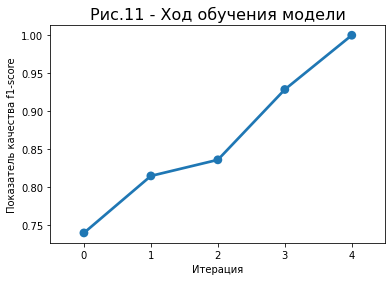

In [ ]:
result = []
for i in np.arange(45, 145, 20):
    cl.fit(x_train2.df.iloc[:i], y_train.iloc[:i]) # Массивы  (125, 16) и (125, 1)
    predict = cl.predict(x_train2.df.iloc[i:i+40]) # Массивы  (40, 16)  и (40, 1)
    #array = y_train[i:i+40].to_numpy()

    res = f1_score(y_train.iloc[i:i+40].values.reshape(-1), predict,  average='macro') # (40, 1) и (40,)
    result.append(res)

fig = sns.pointplot(np.arange(len(result)), result)
#plot.set_title('Рис.11 - Качество предсказания модели')
fig.set_title('Рис.11 - Ход обучения модели', fontsize=16)
fig.set_xlabel('Итерация')
fig.set_ylabel('Показатель качества f1-score');

# Проверка важности

Отобразим индексы датчиков, которые модель считает бесполезными для предсказания.

In [ ]:
cl = LogisticRegression(solver = 'liblinear', penalty = 'l1', C = 5)

cl.fit(x_train2.df, y_train)
#imp = pd.DataFrame(data = cl.coef_[0], index = x_train2.df.columns)
imp = pd.Series(data = cl.coef_[0], index = x_train2.df.columns)
#imp = pd.DataFrame({'sensor_id':imp})

print(f"Индексы датчиков, дающих меньший вклад в предсказание: {np.abs(imp)[np.abs(imp) == 0].index}")
#print(f"Индексы датчиков, дающих меньший вклад в предсказание: {imp[imp['sensor_id'] == 0].index}")

Индексы датчиков, дающих меньший вклад в предсказание: Index(['sensor_2', 'sensor_5', 'sensor_12', 'sensor_17', 'sensor_24',
       'sensor_27', 'sensor_29', 'sensor_36', 'sensor_38'],
      dtype='object')


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Основные датчики, на которых модель строит предсказание:  

In [ ]:
np.abs(imp)[np.abs(imp) > 0].index

Index(['sensor_0', 'sensor_8', 'sensor_15', 'sensor_19', 'sensor_21',
       'sensor_30', 'sensor_33'],
      dtype='object')

# Предсказание с помощью модели

In [ ]:
cl = LogisticRegression(solver = 'liblinear', penalty = 'l1')
cl.fit(x_train2.df, y_train)
sub_predict = cl.predict(x_test2.df)

# отобразим результат
sub_predict

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



array([10,  1, 10, 13,  4,  5, 15,  7,  3, 13,  2,  3,  5,  8, 12,  7,  0,
       11, 12,  4, 12, 14,  4, 10,  0, 10, 15,  5,  6,  7, 15,  1,  2, 15,
       12, 12,  9,  8, 14,  2, 12,  3,  8, 14,  3,  8, 13, 13,  7, 10,  4,
        3,  1, 13, 11, 13, 12,  0,  6,  2,  1,  6, 11,  3,  6,  3,  5, 11,
       13,  5, 14,  2,  7, 15, 15,  4,  2,  6,  0,  7,  8,  5, 12, 11,  1,
        5, 15,  8,  8, 14, 14,  1,  2, 11,  9,  1,  5, 14,  3,  9,  5,  2,
       10, 15,  9,  7, 10, 10,  4,  9,  6, 14,  6, 12,  0, 11,  2,  8,  3,
       11, 13,  7, 10, 10, 11,  5,  6,  0,  9, 10, 12,  8,  0,  8,  7,  3,
       12,  4,  9, 15,  2,  4,  4,  6,  6,  6,  1,  9,  3,  8, 13,  8, 12,
        0,  7,  2,  1,  0, 15,  0,  9, 12, 13,  3,  9,  6])

In [ ]:
# сохраним результат в файл 'submission_3.csv'

submission = pd.read_csv('/content/drive/MyDrive/Motorika/sample_submission.csv')
submission['Class'] = sub_predict

submission.to_csv('/content/drive/MyDrive/Motorika/submission_3.csv', index = False)

Выводы:

В результате исследования получена достоверная модель предсказания показаний датчиков.